mix them pixels yooo

In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier 
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
import linear_mixing as lmx
import scipy.stats as stats
from scipy.optimize import curve_fit

In [2]:
# Magic function to auto-update imported first-party scripts 
%load_ext autoreload
%autoreload 2

# mixing pixels

In [3]:
material_options = {
    "kelp" : ['ecklonia', 'macrocystis', 'undaria'],
    # "brown_algae" : ['ecklonia', 'macrocystis', 'petalonia', 
    #                  'undaria','acrocarpia', 'cystophora', 'carpophyllum', 'durvillaea', 'hormosira', 'phyllospora', 'sargassum', 'scytosiphon'], 
    #"brown_non_kelp" : ['acrocarpia', 'cystophora', 'carpophyllum', 
    #                     'durvillaea', 'hormosira', 'petalonia','phyllospora', #'sargassum', 'scytosiphon'],
    #"red_veg" : ['rhodophyte', 'filamentous_rhodophyte','frondose_rhodophyte',],
    #"green_veg" : ['grass', 'ulva'],
    # "non_brown_autos" : ['grass', 'filamentous_rhodophyte',
    #                      'frondose_rhodophyte', 'rhodophyte', 'ulva'],
    # "all_non_kelp_autos" : ['acrocarpia', 'carpophyllum', 'cystophora', 
    #                         'durvillaea', 'filamentous_rhodophyte','frondose_rhodophyte', 'petalonia', 'grass','hormosira','phyllospora', 'rhodophyte',  'sargassum','scytosiphon','ulva'],
    # "all_non_kelp" : ['acrocarpia', 'barnacle_shells', 'carpophyllum',
    #                   'cystophora', 'durvillaea', 'filamentous_rhodophyte','frondose_rhodophyte', 'gravel', 'grass','hormosira','mussels','petalonia','phyllospora', 'rhodophyte', 'rock','sand', 'sargassum', 'scytosiphon', 'shell_litter','rock', 'ulva', 'worm_castings'],
    "mineral" : ['barnacle_shells', 'gravel', 'mussels', 'rock', 'sand', 
                  'shell_litter', 'worm_castings'],
    }
material_options.keys()

dict_keys(['kelp', 'mineral'])

In [4]:
#Assign fractional cover ranges with simulate within
cover_ranges = {
    "kelp" : (0,0.8),
    #"brown_algae" : (0, 0.5), 
    "brown_non_kelp" : (0,0.8),
    "red_veg" : (0,0.2),
    "green_veg" : (0, 0.5),
    #"non_brown_autos" : (0, 40),
    #"all_non_kelp_autos" : (0, 100),
    #"all_non_kelp" : (0,100),
    "mineral" : (0,0.7),}

In [5]:
data = pd.read_csv("./data/processed/resampled/noisy_Sentinel_2_ABC_resampled.csv", index_col=0)
labels = pd.read_csv("data/labels_prepped.csv", index_col=0)
data = pd.concat([labels["Class"], data], axis = 1)

In [7]:
waters = pd.read_csv("./S2_deep_water_agg.csv", index_col=0)
waters = waters.iloc[:, 4:-3]
print(f"total of {waters.shape[0]} water pixels loaded")
waters.drop_duplicates(inplace = True)
print(f"Total of {waters.shape[0]} unique water pixels kept")
waters= waters/10000
waters.head()


total of 400637 water pixels loaded
Total of 393022 unique water pixels kept


,nbart_blue,nbart_green,nbart_red,nbart_red_edge_1,nbart_red_edge_2,nbart_red_edge_3,nbart_nir_1,nbart_nir_2
1,0.0323,0.0327,0.0163,0.0168,0.0187,0.0195,0.0203,0.0198
2,0.0327,0.0303,0.0162,0.0177,0.0199,0.0210,0.0182,0.0217
3,0.0309,0.0310,0.0174,0.0177,0.0199,0.0210,0.0193,0.0217
4,0.0316,0.0329,0.0181,0.0192,0.0195,0.0211,0.0192,0.0208
6,0.0344,0.0319,0.0200,0.0192,0.0195,0.0211,0.0218,0.0208


In [8]:
mixer = lmx.LinearMixing(materials = material_options, cover_ranges = cover_ranges, pixels = 4000, material_spectra= data, water_spectra = waters)


In [9]:
results, f = mixer.sim_many_pixels()

In [10]:
simulated_pixels, pixel_fpcs = mixer.format_sim_results(results, f)
del results, f
simulated_pixels.head()

,S2A_SR_AV_B2,S2A_SR_AV_B3,S2A_SR_AV_B4,S2A_SR_AV_B5,S2A_SR_AV_B6,S2A_SR_AV_B7,S2A_SR_AV_B8,S2A_SR_AV_B8A
0,0.014097,0.050194,0.035387,0.385182,0.775221,0.774921,0.686797,0.613982
1,0.020786,0.113025,0.037007,0.405740,0.686498,0.734636,0.770615,0.788831
2,0.028959,0.031855,0.039082,0.079335,0.125478,0.174629,0.238657,0.281199
3,0.223060,0.279639,0.262933,0.348460,0.387753,0.347548,0.265127,0.208248
4,0.063230,0.278246,0.262248,0.500196,0.678267,0.718268,0.728778,0.729281


In [11]:
pixel_fpcs.head()

,kelp,mineral,water,non-water_comps
0,0.765244,0.045539,0.189217,2
1,0.796209,0.000000,0.203791,1
2,0.000000,0.441074,0.558926,1
3,0.143092,0.308618,0.548290,2
4,0.194992,0.629682,0.175325,2


In [ ]:
# Plot the components of the simulated pixels

args = {'log' : True} 

fig, ax = plt.subplots(3,2)
ax[0,0].hist(pixel_fpcs['kelp'], bins = 50,range = (0.00000000000, max(pixel_fpcs['kelp'])), **args) #log = True)
ax[0,1].hist(pixel_fpcs['brown_non_kelp'], bins = 50, range = (0.00000000000, max(pixel_fpcs['brown_non_kelp'])), **args)
ax[1,0].hist(pixel_fpcs['red_veg'], bins = 50, range = (0.00000000000, max(pixel_fpcs['red_veg'])), **args)
ax[1,1].hist(pixel_fpcs['green_veg'], bins = 50, range = (0.00000000000, max(pixel_fpcs['green_veg'])), **args)
ax[2,0].hist(pixel_fpcs['mineral'], bins = 50, range = (0.00000000000, max(pixel_fpcs['mineral'])), **args)
ax[2,1].hist(pixel_fpcs['water'], bins = 50)

# fig.savefig(r"C:\Users\s4770224\Documents\Work\Writing\Figures\Obj1\part2\simulated_pixel_fpcs_histograms.svg")
# plt.show()

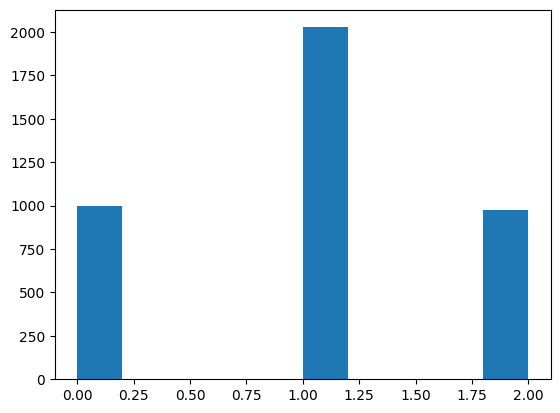

In [151]:
plt.hist(pixel_fpcs['non-water_comps'])
# fig.savefig(r"C:\Users\s4770224\Documents\Work\Writing\Figures\Obj1\part2\simulated_pixel_component_counts.svg")
plt.show()

In [21]:
#simulated_pixels.to_csv("data/mixed_sims/kbrgm_simulated_pixels_18112025.csv")
# pixel_fpcs.to_csv("data/mixed_sims/kbrgm_pixel_fpcs_18112025.csv")

In [15]:
# Define what you simulated
label_level = "kom"
keep_list = ["kelp", "water", "mineral"]

# Add water to classifier training set 
sample_idx = np.random.choice(waters.index, size = 1000, replace = False)
water_labels = pd.DataFrame("water", index = sample_idx, columns = labels.columns)
water_sample = waters.iloc[sample_idx, :]
water_sample.columns = data.columns[1:]
data_watered = pd.concat([data, water_sample], axis = 0)
labels_watered = pd.concat([labels, water_labels], axis = 0).set_index(data_watered.index)
data_watered = pd.concat([labels_watered, data_watered.iloc[:, 1:]], axis = 1)


In [60]:
# Filter training data to only mixed pixel components
data_watered = data_watered[data_watered[label_level].isin(keep_list)]
water_endmember = data_watered[label_level] == "water"


In [19]:
# Extract PCA components and transform dataset
deco = PCA(8)
deco.fit(data_watered.iloc[:,8:])
decomposed_train = deco.transform(data_watered.iloc[:, 8:])
decomposed_test = deco.transform(simulated_pixels)
comps = deco.components_

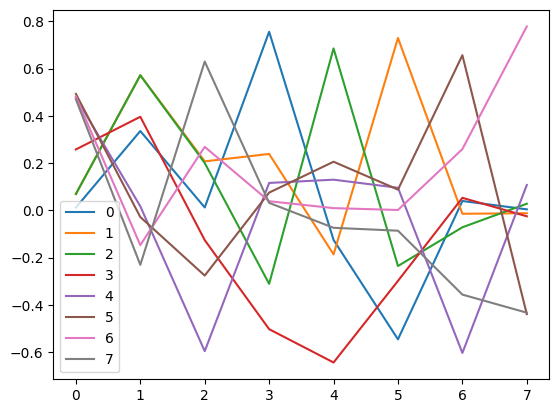

In [20]:
plt.plot(comps, label = range(comps.shape[1]))
plt.legend()
plt.show()

In [158]:
# divide the dataset into training and testing
x_train, x_test, y_train, y_test = train_test_split(decomposed_test, pixel_fpcs["water"], train_size = 0.7, random_state = 4)
x_train = pd.DataFrame(x_train)
x_test = pd.DataFrame(x_test)

In [160]:
regger = RandomForestRegressor(n_estimators = 1000, criterion = "squared_error", random_state=4, oob_score= True)
# classer.fit(data_watered.iloc[:, 1:], labels_watered["kbrgm"])
regger.fit(x_train, y_train)

# Inspect random forest outputs
print(regger.oob_score_)
print(regger.feature_importances_)

0.9902161942514536
[0.93792788 0.00845736 0.03016941 0.00463322 0.00373696 0.01039181
 0.00236996 0.00231339]


In [161]:
regger_pred = pd.DataFrame(regger.predict(x_test))
# g.to_csv("kbrgm_simulated_pixel_class_probs.csv")

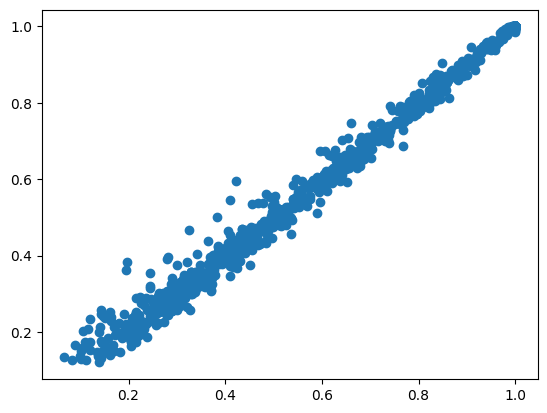

In [162]:
# Plot all prediction results
plt.scatter(y_test, regger_pred)


In [163]:
regger_pred.set_index(y_test.index, inplace = True)
regger_pred.columns = [100]
pd.concat([y_test, regger_pred], axis = 1).corr()**2

,water,100
water,1.000000,0.991879
100,0.991879,1.000000


In [167]:
# Add predicted water fraction to testing
x_test.index = y_test.index
x_test_2 = pd.concat([x_test, regger_pred], axis = 1, ignore_index = True)
print(f"Testing dataset now of shape { x_test_2.shape}")

# Add predicted water to training data
h= pd.DataFrame(regger.predict(x_train))
h.set_index(y_train.index, inplace = True)
h.columns = [100]
x_train.index = y_train.index
x_train_2 = pd.concat([x_train, h], axis = 1)
print(f"Training dataset now of shape { x_train_2.shape}")

Testing dataset now of shape (1200, 9)
Training dataset now of shape (2800, 9)


In [168]:
# Make new testing label set of only non-water materials
y_test_dry = pixel_fpcs.loc[x_test.index, :]
y_test_dry.drop(["non-water_comps"], axis = 1, inplace = True)

# Make new training label set of only non-water materials
y_train_dry = pixel_fpcs.loc[x_train.index, :]
y_train_dry.drop(["non-water_comps"], axis = 1, inplace = True)

# Train new RFC for soft classification of only non-water materials
classer = RandomForestClassifier(n_estimators = 1000, criterion = "gini", random_state=4, oob_score= True)


In [169]:
y_train_dry["majority_comp"] = y_train_dry.idxmax(axis = 1)
y_train_dry.head()

,kelp,mineral,water,majority_comp
2478,0.000000,0.000000,1.000000,water
3531,0.003298,0.618109,0.378593,mineral
2561,0.699370,0.110895,0.189736,kelp
1321,0.165447,0.000000,0.834553,water
2405,0.418205,0.000000,0.581795,water


In [170]:
x_train_2. columns

Index([0, 1, 2, 3, 4, 5, 6, 7, 100], dtype='int64')

In [171]:
classer.fit(x_train_2, y_train_dry["majority_comp"])

RandomForestClassifier(n_estimators=1000, oob_score=True, random_state=4)

In [172]:
# Inspect random forest outputs
print(classer.oob_score_)
print(classer.feature_importances_)

0.9760714285714286
[0.23821065 0.1498454  0.08557743 0.02898496 0.0248261  0.05643686
 0.02413618 0.00981072 0.38217168]


In [173]:
# Predict non-water materials on testing set 
pred_all = pd.DataFrame(classer.predict_proba(x_test_2))

In [198]:
pred_all.index = y_test_dry.index

In [200]:
adjusted_pred = pred_all.copy()
adjusted_pred[3] = regger_pred[100]+0.000000000001 # water fraction
adjusted_pred[4] = 1-regger_pred[100]+0.00000000001 # nonwater fraction
# adjusted_pred.iloc[:, :3] = adjusted_pred.iloc[:, :3].multiply(adjusted_pred[4], axis = 0)
adjusted_pred[0] = (adjusted_pred[0] + (adjusted_pred[0]/adjusted_pred[4]))*adjusted_pred[3]
adjusted_pred[1] = (adjusted_pred[1] + (adjusted_pred[1]/adjusted_pred[4]))*adjusted_pred[3]
adjusted_pred[5] = np.sum(adjusted_pred.iloc[:, [0,1,3]], axis = 1)

adjusted_pred.head()

,0,1,2,3,4,5
3264,0.003574,0.000000,0.999,0.739249,2.607511e-01,0.742823
2559,0.000000,0.000000,1.000,0.999534,4.658697e-04,0.999534
15,0.000000,0.000000,1.000,0.999797,2.031656e-04,0.999797
1872,0.252109,0.065555,0.026,0.149863,8.501370e-01,0.467527
491,0.000000,0.000000,1.000,1.000000,1.000000e-11,1.000000


In [201]:
y_test_dry.head()

,kelp,mineral,water
3264,0.263144,0.00000,0.736856
2559,0.000000,0.00000,1.000000
15,0.000000,0.00000,1.000000
1872,0.463799,0.38942,0.146782
491,0.000000,0.00000,1.000000


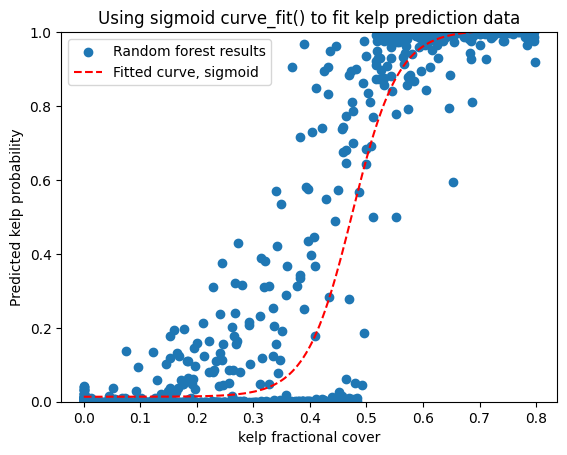

In [186]:
# Assign x and y variables once
mat = "kelp"
x = y_test_dry[mat]
y = pred_all[0]+0.0000000001

# sigmoid calculation
def sigmoid(x, L ,x0, k, b):
    y = L / (1 + np.exp(-k*(x-x0))) + b
    return (y)


p0 = [max(y), np.mean(x), 1, min(y)] # this is an mandatory initial guess

popt, pcov = curve_fit(sigmoid, x, y, p0, method='trf')
#popt[3] = 0
x_fitted_weighted = np.linspace(np.min(x), np.max(x), 500)
y_fitted_sigmoid = sigmoid(x_fitted_weighted, *popt)


# Plot
ax = plt.axes()
ax.scatter(x, y, label='Random forest results')
ax.plot(x_fitted_weighted, y_fitted_sigmoid, '--', color = "red", label='Fitted curve, sigmoid')
ax.set_title(f'Using sigmoid curve_fit() to fit {mat} prediction data')
ax.set_ylabel(f'Predicted {mat} probability')
ax.set_ylim(0, 1)
ax.set_xlabel(f'{mat} fractional cover')
ax.legend()

In [188]:
# Access sigmoid function parameters
popt
#array([9.93195924e-01, 4.90803282e-01, 2.15039499e+01, 1.11500989e-02])

array([9.92112476e-01, 4.74886095e-01, 2.45130183e+01, 1.34586070e-02])

In [189]:
ssregression = []
sst = []
mean = np.mean(pred_all[1])
for f in pred_all[1]:
    pred_f = sigmoid(f, *popt)
    diff = (f - pred_f)**2
    ssregression.append(diff)
    sst.append((f-mean)**2)

ssregression = np.sum(ssregression)
sst = np.sum(sst)

r_s = 1- (ssregression/sst)
print(f" R squared is equal to {r_s}")


 R squared is equal to 0.9372637852140342


Text(0.5, 0, 'Fractional cover of water')

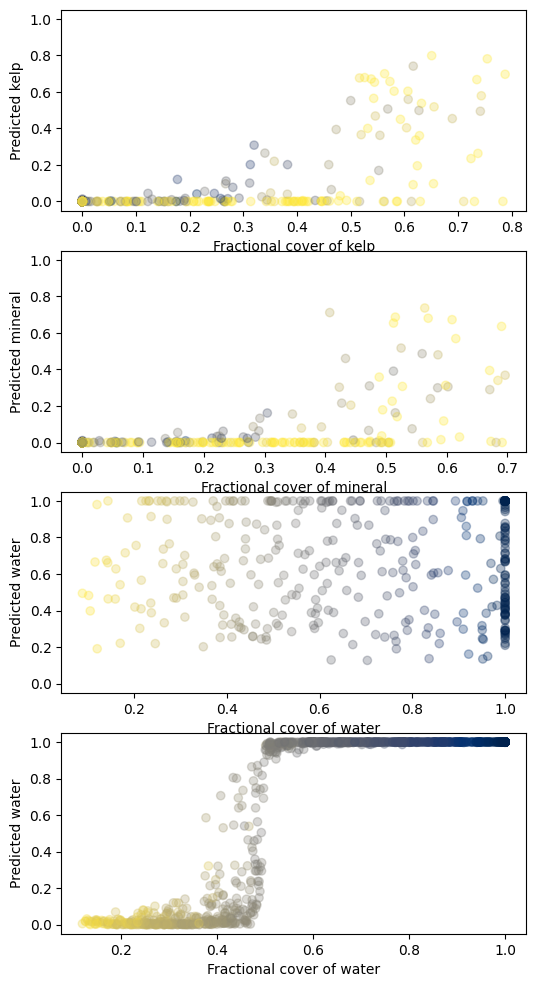

In [193]:
# Plotting adjusted results 

fig, axes = plt.subplots(4,  1, sharey = True, figsize = (6,12))
axes[0].scatter(y_test_dry["kelp"], adjusted_pred[0], c = y_test_dry["mineral"], cmap = "cividis_r", alpha = 0.3)
axes[0].set_ylabel(f"Predicted kelp")
axes[0].set_xlabel(f"Fractional cover of kelp")

axes[1].scatter(y_test_dry["mineral"], adjusted_pred[1], c = y_test_dry["kelp"], cmap = "cividis_r", alpha = 0.3)
axes[1].set_ylabel(f"Predicted mineral")
axes[1].set_xlabel(f"Fractional cover of mineral")

axes[2].scatter(y_test_dry["water"], adjusted_pred[3], c = y_test_dry["water"], cmap = "cividis_r", alpha = 0.3)
axes[2].set_ylabel(f"Predicted water")
axes[2].set_xlabel(f"Fractional cover of water")

axes[3].scatter(x_test_2[8], pred_all[2], c = y_test_dry["water"], cmap = "cividis_r", alpha = 0.3)
axes[3].set_ylabel(f"Predicted water")
axes[3].set_xlabel(f"Fractional cover of water")


Text(0.5, 0, 'Fractional cover of water')

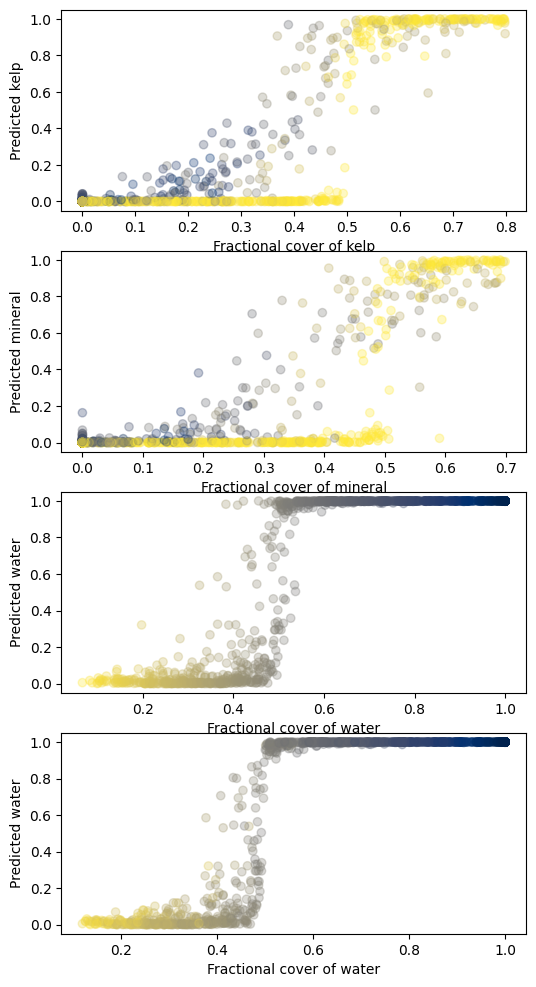

In [178]:
# Plot prediciton results

fig, axes = plt.subplots(4,  1, sharey = True, figsize = (6,12))
axes[0].scatter(y_test_dry["kelp"], pred_all[0], c = y_test_dry["mineral"], cmap = "cividis_r", alpha = 0.3)
axes[0].set_ylabel(f"Predicted kelp")
axes[0].set_xlabel(f"Fractional cover of kelp")

axes[1].scatter(y_test_dry["mineral"], pred_all[1], c = y_test_dry["kelp"], cmap = "cividis_r", alpha = 0.3)
axes[1].set_ylabel(f"Predicted mineral")
axes[1].set_xlabel(f"Fractional cover of mineral")

axes[2].scatter(y_test_dry["water"], pred_all[2], c = y_test_dry["water"], cmap = "cividis_r", alpha = 0.3)
axes[2].set_ylabel(f"Predicted water")
axes[2].set_xlabel(f"Fractional cover of water")

axes[3].scatter(x_test_2[8], pred_all[2], c = y_test_dry["water"], cmap = "cividis_r", alpha = 0.3)
axes[3].set_ylabel(f"Predicted water")
axes[3].set_xlabel(f"Fractional cover of water")


Text(0.5, 0, 'Probability of mineral')

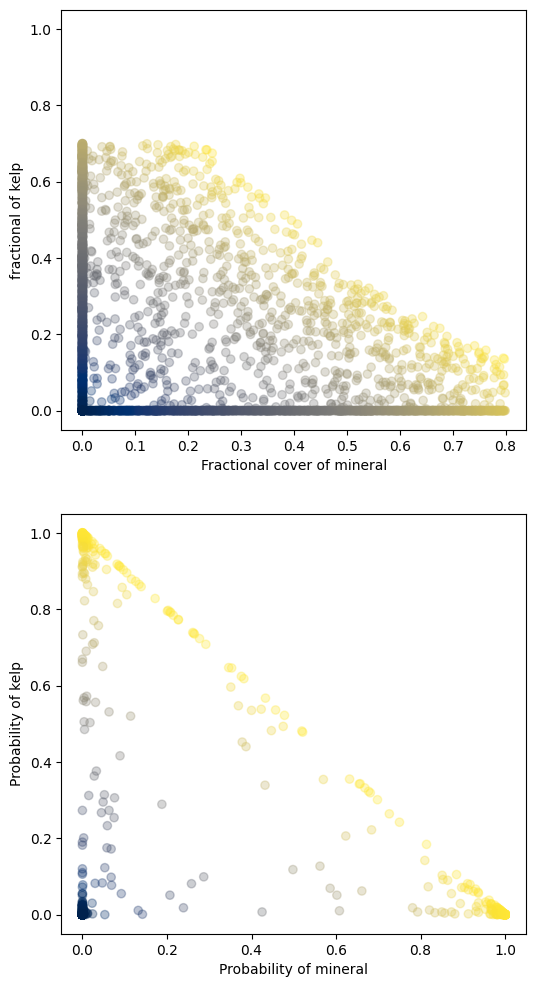

In [106]:
# Plotting kelp by mineral, prediction and FPC

fig, axes = plt.subplots(2,  1, sharey = True, figsize = (6,12))
axes[0].scatter(pixel_fpcs["kelp"], pixel_fpcs["mineral"], c = pixel_fpcs["water"], cmap = "cividis_r", alpha = 0.3)
axes[0].set_ylabel(f"fractional of kelp")
axes[0].set_xlabel(f"Fractional cover of mineral")
axes[1].scatter(pred_all[0], pred_all[1], c = pred_all[2], cmap = "cividis_r", alpha = 0.3)
axes[1].set_ylabel(f"Probability of kelp")
axes[1].set_xlabel(f"Probability of mineral")


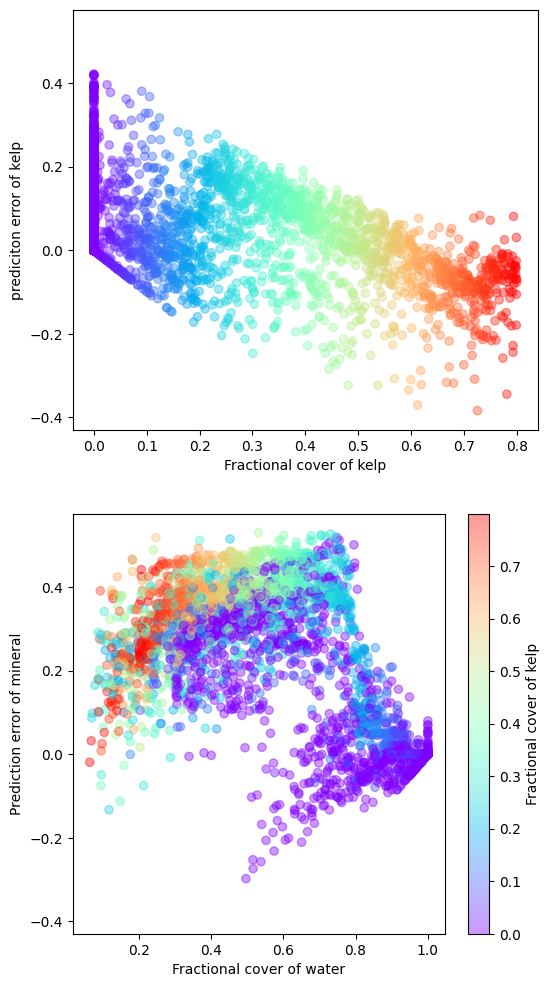

In [26]:
# Plotting prediction error by FPC

fig, axes = plt.subplots(2,  1, sharey = True, figsize = (6,12))
axes[0].scatter(pixel_fpcs["kelp"], regger_pred[0] - pixel_fpcs['kelp'], c = pixel_fpcs["kelp"], cmap = "rainbow", alpha = 0.4)
axes[0].set_ylabel(f"prediciton error of kelp")
axes[0].set_xlabel(f"Fractional cover of kelp")
axes[1].scatter(pixel_fpcs["water"], regger_pred[1]- pixel_fpcs['mineral'], c = pixel_fpcs["kelp"], cmap = "rainbow", alpha = 0.4)
axes[1].set_ylabel(f"Prediction error of mineral")
axes[1].set_xlabel(f"Fractional cover of water")
fig.colorbar(axes[1].collections[0], ax=axes[1], label='Fractional cover of kelp')


C:\Users\s4770224\AppData\Local\Temp\ipykernel_6232\2375160040.py:17: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


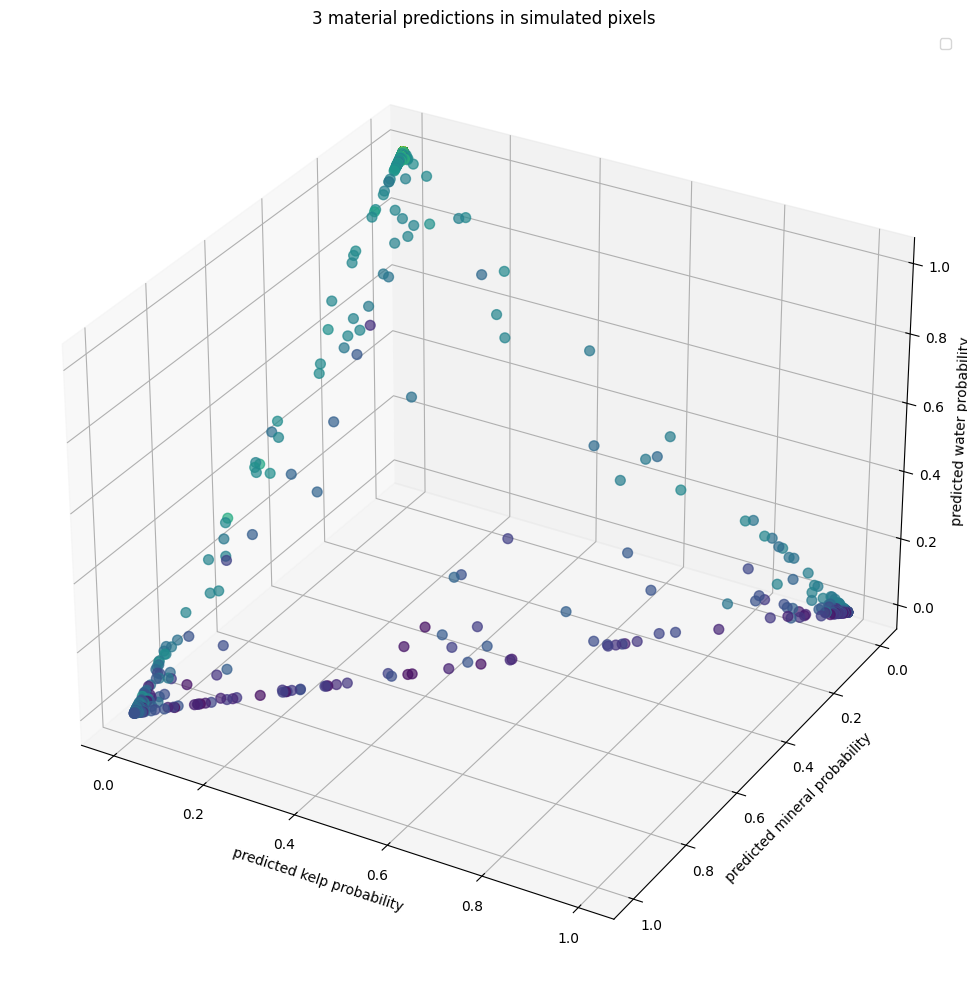

In [110]:
# 3D predicition plot
components = [0,1,2]

# Plot 3-way predictions 
fig = plt.figure(figsize=(14, 10))
ax = fig.add_subplot(projection='3d')
x, y, z = components

ax.scatter(pred_all[x], pred_all[y], pred_all[z],c=y_test_dry["water"], cmap = "viridis", alpha=0.7, s=50) ,
ax.yaxis.set_inverted(True)
plt.xlabel('predicted kelp probability')
plt.ylabel('predicted mineral probability')
if len(components) == 3:
    ax.set_zlabel('predicted water probability')
plt.title('3 material predictions in simulated pixels')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

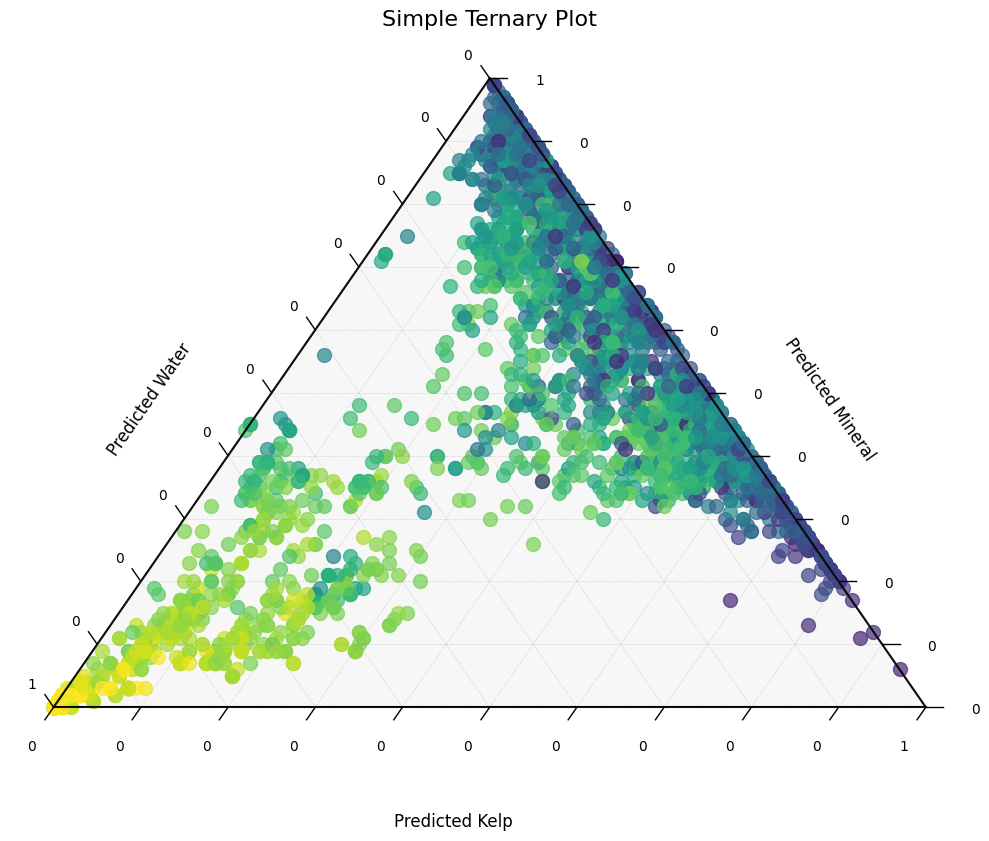

In [78]:
# Ternary plot - UNFINISHED/INCORRECT

# Format data for ternary plot
points = []
for row in range(regger_pred.shape[0]):
    x,y,z = regger_pred.iloc[row, 0], regger_pred.iloc[row, 1], pred_all.iloc[row, 2]
    points.append((x,y,z))
    
points_dict = {}
for x,y,z in points:
    points_dict[(x,y)] = z

# Create the figure
fig, ax = plt.subplots(figsize=(10, 8))
fig.patch.set_facecolor('white')

# Create ternary axes (scale=1 for proportions, scale=100 for percentages)
tax = ternary.TernaryAxesSubplot(ax=ax, scale=1.0)

# Set labels for each vertex
tax.set_title("Simple Ternary Plot", fontsize=16, pad=20)
tax.left_axis_label("Predicted Water", fontsize=12, offset=0.15)
tax.right_axis_label("Predicted Mineral", fontsize=12, offset=0.15)
tax.bottom_axis_label("Predicted Kelp", fontsize=12, offset=0.15)

# Draw boundary and gridlines
tax.boundary(linewidth=1.5)
tax.gridlines(multiple=0.1, color="gray", linewidth=0.5, alpha=0.5)

# Plot the data points
count = 0
for point in points:
    tax.scatter([point], marker='o', s=100, c=pixel_fpcs["water"][count], cmap = "viridis", alpha=0.7)
    count +=1

# Clear matplotlib axes
tax.clear_matplotlib_ticks()
tax.get_axes().axis('off')
tax.ticks(axis='lbr', linewidth=1, multiple=0.1, offset=0.02)

# Display the plot
plt.tight_layout()
plt.show()

